# Hot Rebound Strategy v4 Balanced Optimization

V4 keeps the v2 stock-selection logic and uses a grid-tested balanced sell rule.

Sell logic:

1. Stop loss: 8%.
2. Take profit: 28%.
3. Max holding window: 3 trading days.
4. If neither stop loss nor take profit is reached, exit near the end of the holding window.

Grid-search note: user idea 9% stop / 25% take / 5 days was weaker than V3 in this sample.


In [19]:
%reload_ext autoreload
%autoreload 2

# === 基础依赖与运行环境 ===
# notebook 里频繁改代码时，autoreload 可以自动热更新已导入的本地模块，
# 避免每次修改完都手动重启内核。
from my_utils.fun import *
from my_utils.trade_fun import *
import polars as pl
import pandas as pd
import datetime as dt
import os

# 单独给这套策略写日志，方便回溯每一次回测/调参的输入和结果。
logging = get_logger(log_file='log/hot_rebound_strategy_v4.log', inherit=False)

# === 回测区间 ===
# 起始日期固定，结束日期默认取今天，便于持续回测最新数据。
start_date = dt.date(2024, 1, 1)
end_date = dt.date.today()

# === 策略参数统一管理 ===
# 把所有阈值集中放在一个字典里，后续做参数优化、版本对比或复现结果时会更清楚。
params_dict = {
    # 热度统计窗口：统计最近多少个交易日内的涨停/封板行为
    'popularity_window': 15,
    # “最近出现过热点”的回看周期：控制补涨时点不要离热点太远
    'hot_lookback': 7,
    # 回看最近高点的窗口：用于计算回撤幅度
    'pullback_window': 20,
    # 最近窗口内至少要有多少次涨停，才认为有持续人气
    'min_limit_up_count': 2,
    # 最近窗口内允许的“一字板/强封板”最大数量
    'max_yzb_count': 2,
    # 综合人气分数阈值：达到这个值就认为“足够热”
    'popularity_score_threshold': 0.72,
    # 成交额排名阈值
    'amount_rank_threshold': 0.90,
    # 换手率排名阈值
    'turnover_rank_threshold': 0.88,
    # 回撤幅度下限：越接近前高回撤越小，通常越偏强势
    'pullback_low': -12,
    # 回撤幅度上限：回撤不能太深，避免弱势补涨
    'pullback_high': -4,
    # 开盘相对昨收的低开/高开范围下限
    'open_pct_low': -3.5,
    # 开盘相对昨收的低开/高开范围上限
    'open_pct_high': 2.5,
    # 自由流通市值下限，过滤太小盘和过于极端标的
    'mv_min': 30,
    # 自由流通市值上限，过滤过大盘股
    'mv_max': 800,
    # 近10日涨停均换手率下限
    'avg_limit_turnover_min': 3,
    # 近10日涨停均换手率上限
    'avg_limit_turnover_max': 35,
    # 当日最低基础换手要求
    'min_turn_over': 2,
    # 近5日量比下限
    'min_volume_ratio_5': 0.8,
    # 止盈幅度
    'take_profit_pct': 0.28,
    # 止损幅度
    'stop_loss_pct': 0.08,
    # 最大持仓天数
    'max_holding_days': 3,
    # 交易手续费/滑点等综合费率假设
    'fee_rate': 0.004,
    # 仓位权重，用于后面的资金回报折算
    'position_weight': 0.45,
    # 网格优化后使用的补充过滤条件：回撤不超过这个值
    'opt_pullback_high': -5,
    # 网格优化后使用的涨停均换手率下限
    'opt_avg_limit_turnover_min': 6.3,
    # 网格优化后使用的涨停均换手率上限
    'opt_avg_limit_turnover_max': 8.5,
}

# === 运行摘要 ===
# 这些打印和日志方便你一眼确认当前策略版本、核心阈值和卖出规则。
print('strategy_version: hot_rebound_v4_balanced_optimization')
print(f"optimized_filter: pullback_pct <= {params_dict['opt_pullback_high']}, avg_limit_turnover_10 in [{params_dict['opt_avg_limit_turnover_min']}, {params_dict['opt_avg_limit_turnover_max']}]")
print(f"position_weight: {params_dict['position_weight']:.0%}")
logging.info(f'backtest period: {start_date} to {end_date}')
logging.info(f'params: {params_dict}')

print('sell_logic: stop_loss=8%, take_profit=28%, max_holding_days=3')

backtest period: 2024-01-01 to 2026-05-06
params: {'popularity_window': 15, 'hot_lookback': 7, 'pullback_window': 20, 'min_limit_up_count': 2, 'max_yzb_count': 2, 'popularity_score_threshold': 0.72, 'amount_rank_threshold': 0.9, 'turnover_rank_threshold': 0.88, 'pullback_low': -12, 'pullback_high': -4, 'open_pct_low': -3.5, 'open_pct_high': 2.5, 'mv_min': 30, 'mv_max': 800, 'avg_limit_turnover_min': 3, 'avg_limit_turnover_max': 35, 'min_turn_over': 2, 'min_volume_ratio_5': 0.8, 'take_profit_pct': 0.28, 'stop_loss_pct': 0.08, 'max_holding_days': 3, 'fee_rate': 0.004, 'position_weight': 0.45, 'opt_pullback_high': -5, 'opt_avg_limit_turnover_min': 6.3, 'opt_avg_limit_turnover_max': 8.5}


strategy_version: hot_rebound_v4_balanced_optimization
optimized_filter: pullback_pct <= -5, avg_limit_turnover_10 in [6.3, 8.5]
position_weight: 45%
sell_logic: stop_loss=8%, take_profit=28%, max_holding_days=3


## 1. 加载数据

In [20]:
# === 读取日线数据 ===
# ts_stock_all_data 是策略计算的基础行情表，后续大部分特征都从这里来。
stock_data = read_day_data(start_date=start_date, end_date=end_date, file_path='ts_stock_all_data')
# 核心价格字段缺失会影响涨停、均线、回撤等计算，先统一清掉。
stock_data = stock_data.drop_nulls(subset=['open', 'high', 'low', 'close', 'pre_close', 'limit_up', 'limit_down'])

# === 读取估值/成交额辅助数据 ===
# daily_basic 里有自由流通股本等字段，可以进一步推导自由流通市值。
market_value = read_day_data(start_date=start_date, end_date=end_date, file_path='ts_daily_basic')
market_value = market_value.with_columns([
    # 自由流通市值 = 自由流通股本 * 收盘价，单位这里统一换算成“亿”级别的可比口径。
    (pl.col('free_share') * pl.col('close') / 1e4).alias('free_float_mv')
])

# 把自由流通市值和换手率补回行情主表，供后面的筛选条件使用。
stock_data = stock_data.join(
    market_value.select(['code', 'trading_date', 'free_float_mv', 'turnover_rate']),
    on=['code', 'trading_date'],
    how='left'
)

# 清理一些当前策略没用到的列，减少 DataFrame 体积，也让后续调试更干净。
drop_cols = ['change', 'total_share', 'attack', 'activity', 'pe', 'float_share', 'buying', 'selling', 'swing', 'strength', 'avg_turnover']
drop_cols = [col for col in drop_cols if col in stock_data.columns]
if drop_cols:
    stock_data = stock_data.drop(drop_cols)

# 排序是为了后面所有按股票代码的滚动窗口计算都严格按时间顺序进行。
stock_data = stock_data.sort(['code', 'trading_date'])
logging.info(f'加载数据完成，共 {stock_data.height} 条记录')
stock_data.head()

加载数据完成，共 2793103 条记录


code,trading_date,open,high,low,close,pre_close,pct,volume,amount,limit_up,limit_down,type,type_name,name,vol_ratio,turn_over,industry,area,float_mv,total_mv,avg_price,free_float_mv,turnover_rate
str,date,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,str,str,str,f64,f64,str,str,f64,f64,f64,f64,f64
"""SHSE.600000""",2024-01-02,6.63,6.65,6.6,6.6,6.62,-0.3021,220667.0,14606.6304,7.28,5.96,null,null,"""浦发银行""",0.99,0.08,"""银行""","""上海""",1937.24,1937.24,6.62,629.093694,0.0752
"""SHSE.600000""",2024-01-03,6.59,6.65,6.59,6.64,6.6,0.6061,182036.54,12063.9706,7.26,5.94,null,null,"""浦发银行""",0.75,0.06,"""银行""","""上海""",1948.98,1948.98,6.63,632.906383,0.062
"""SHSE.600000""",2024-01-04,6.64,6.67,6.55,6.62,6.64,-0.3012,288859.78,19058.061,7.3,5.98,null,null,"""浦发银行""",1.13,0.1,"""银行""","""上海""",1943.11,1943.11,6.6,631.000039,0.0984
"""SHSE.600000""",2024-01-05,6.6,6.76,6.59,6.68,6.62,0.9063,444213.87,29697.6886,7.28,5.96,null,null,"""浦发银行""",1.61,0.15,"""银行""","""上海""",1960.73,1960.73,6.69,636.719102,0.1513
"""SHSE.600000""",2024-01-08,6.68,6.71,6.56,6.59,6.68,-1.3473,375203.37,24797.7825,7.35,6.01,null,null,"""浦发银行""",1.27,0.13,"""银行""","""上海""",1934.31,1934.31,6.61,628.140552,0.1278


## 2. 特征工程

In [21]:
# === 工具函数：按交易日做降序百分位排名 ===
# 这里用来衡量某个股票在“当天全市场”里的相对位置，数值越大表示越靠前。
def rank_pct_desc(expr: pl.Expr, by: str) -> pl.Expr:
    # group_size 是每个分组的样本数；如果某天只有 1 只股票参与，直接返回 0 避免除零。
    group_size = pl.len().over(by)
    # 降序排名：数值越大，rank 越靠前。
    rank_desc = expr.rank(descending=True, method='average').over(by)
    return (
        pl.when(group_size <= 1)
        .then(0.0)
        # 转成 0~1 的百分位，1 表示当天最强，0 表示当天最弱。
        .otherwise((group_size - rank_desc) / (group_size - 1))
        .cast(pl.Float64)
    )


# === 工具函数：计算距离上一次“热股日”过去了多少天 ===
# 这个值越小，说明股票越接近最近一次市场关注点，越符合“热点延伸/补涨”思路。
def calc_days_since_hot(group: pl.DataFrame) -> pl.DataFrame:
    hot_list = group['is_hot_today'].to_list()
    result = []
    last_hot_idx = None

    for idx, is_hot in enumerate(hot_list):
        if is_hot:
            # 当前就是热股日，距离上一次热股日记 0 天。
            last_hot_idx = idx
            result.append(0)
        elif last_hot_idx is None:
            # 还没出现过热股日，先记空值，表示没有可参考的“上一次热点”。
            result.append(None)
        else:
            # 与最近一次热股日的间隔天数。
            result.append(idx - last_hot_idx)

    return group.with_columns([
        pl.Series('days_since_hot', result, dtype=pl.Int64)
    ])

In [22]:
# === 第一层：基础技术/行为特征 ===
# 这些函数都来自 fun.py，主要负责把原始行情转成可直接用于选股的标签。
stock_data = mark_limit_status(stock_data)
stock_data = mark_limit_desc(stock_data)
stock_data = mark_last_limit_desc(stock_data)
# 统计涨停日的平均换手，帮助衡量“板的质量”和资金参与程度。
stock_data = cal_limit_avg_turnover(stock_data, window=10)
# 常用均线作为趋势过滤器，避免只追超跌、不看趋势。
stock_data = add_sma(stock_data, window=5)
stock_data = add_sma(stock_data, window=10)
stock_data = add_sma(stock_data, window=20)
# 近 5 日量比，用来衡量近期成交活跃程度。
stock_data = add_pre_n_ratio(stock_data, field='volume', n=5)

stock_data = stock_data.with_columns([
    # 开盘相对昨收的涨跌幅：用于判断是否存在合适的低开/高开位置。
    ((pl.col('open') - pl.col('pre_close')) / pl.col('pre_close') * 100).alias('open_pct'),
    # 实体涨跌幅：用于过滤当天是否真的收阳或至少不是弱反弹。
    ((pl.col('close') - pl.col('open')) / pl.col('open') * 100).alias('body_pct'),
    # VWAP 的简化近似：成交额 / 成交量。
    ((pl.col('amount') * 100 / pl.col('volume')).fill_nan(0.0).fill_null(0.0)).alias('vwap'),
    # 一字板/强封板标记：开盘和收盘都接近涨停价，说明封板强度较高。
    ((pl.col('open') >= pl.col('limit_up') * 0.999) & (pl.col('close') >= pl.col('limit_up') * 0.999)).alias('is_yzb'),
])

popularity_window = params_dict['popularity_window']
pullback_window = params_dict['pullback_window']

stock_data = stock_data.with_columns([
    # 过去 popularity_window 天内的涨停次数，shift(1) 是为了只看历史，不把当天自己算进去。
    pl.col('is_limit_up').cast(pl.Int64).rolling_sum(window_size=popularity_window, min_samples=1).over('code').shift(1).alias(f'limit_up_count_{popularity_window}'),
    # 过去 popularity_window 天内的一字板次数，同样排除当天。
    pl.col('is_yzb').cast(pl.Int64).rolling_sum(window_size=popularity_window, min_samples=1).over('code').shift(1).alias(f'yzb_count_{popularity_window}'),
    # 最近 pullback_window 天的最高价，用于衡量当前距离阶段高点的回撤。
    pl.col('high').rolling_max(window_size=pullback_window, min_samples=1).over('code').shift(1).alias(f'recent_high_{pullback_window}'),
])

stock_data = stock_data.with_columns([
    # 回撤幅度：收盘价相对近期高点下跌了多少百分比，越接近 0 说明越强。
    ((pl.col('close') - pl.col(f'recent_high_{pullback_window}')) / pl.col(f'recent_high_{pullback_window}') * 100).fill_nan(0.0).fill_null(0.0).alias('pullback_pct'),
    # 当天成交额的全市场百分位：越高说明越有资金关注。
    rank_pct_desc(pl.col('amount'), 'trading_date').alias('amount_rank_pct'),
    # 当天换手率的全市场百分位：越高说明越活跃。
    rank_pct_desc(pl.col('turn_over'), 'trading_date').alias('turnover_rank_pct'),
])

stock_data = stock_data.with_columns([
    # 将量比压缩到 0~1 的得分，避免极端值把综合分数拉歪。
    (pl.col('volume_ratio_5').clip(0.0, 3.0) / 3.0).alias('volume_ratio_score'),
    # 将最近涨停次数压缩到 0~1 的得分，体现“板数/热度”的贡献。
    (pl.col(f'limit_up_count_{popularity_window}').clip(0.0, 4.0) / 4.0).alias('board_score'),
])

stock_data = stock_data.with_columns([
    # 综合人气分数：把成交额、换手、量比、涨停次数按权重合成一个热度指标。
    (
        pl.col('amount_rank_pct') * 0.35 +
        pl.col('turnover_rank_pct') * 0.25 +
        pl.col('volume_ratio_score') * 0.20 +
        pl.col('board_score') * 0.20
    ).alias('popularity_score')
])

stock_data = stock_data.with_columns([
    # 是否“当天热股”：要么综合热度足够高，要么成交额/换手/涨停次数同时达到较强标准。
    (
        (pl.col('popularity_score') >= params_dict['popularity_score_threshold']) |
        (
            (pl.col('amount_rank_pct') >= params_dict['amount_rank_threshold']) &
            (pl.col('turnover_rank_pct') >= params_dict['turnover_rank_threshold']) &
            (pl.col(f'limit_up_count_{popularity_window}') >= params_dict['min_limit_up_count'])
        )
    ).alias('is_hot_today')
])

# 按股票分组计算“距离最近一次热股日过去了多少天”。
stock_data = stock_data.group_by('code').map_groups(calc_days_since_hot)
stock_data = stock_data.with_columns([
    # 下一交易日用于实盘/回测的执行日，也就是信号产生后真正买入的那一天。
    pl.col('trading_date').shift(-1).over('code').alias('next_trading_date')
])

logging.info('高人气补涨特征计算完成')
stock_data.select(['code', 'trading_date', 'amount_rank_pct', 'turnover_rank_pct', 'popularity_score', 'days_since_hot']).head()

高人气补涨特征计算完成


code,trading_date,amount_rank_pct,turnover_rank_pct,popularity_score,days_since_hot
str,date,f64,f64,f64,i64
"""SHSE.600000""",2024-01-02,0.736832,0.001572,null,null
"""SHSE.600000""",2024-01-03,0.705443,0.000884,0.302122,null
"""SHSE.600000""",2024-01-04,0.840637,0.002162,0.390403,null
"""SHSE.600000""",2024-01-05,0.886837,0.004715,0.440038,null
"""SHSE.600000""",2024-01-08,0.880157,0.003536,0.397032,null


## 3. 生成信号

In [23]:
# === 选股过滤器 ===
# 代码后缀用于过滤科创板/创业板/北交所等不在当前策略范围内的标的。
code_part = pl.col('code').str.split('.').list[1]
# ST 个股在大多数策略中都要剔除，避免退市风险和交易约束带来的噪音。
non_st_filter = ~(pl.col('type').is_not_null() & (pl.col('type') == 'ST'))
# 这里只保留主板/非创业科创/北交所以外的标的，匹配当前策略的实盘池。
non_gem_kc_filter = ~(code_part.str.starts_with('30') | code_part.str.starts_with('688') | code_part.str.starts_with('8'))

# === 核心信号条件 ===
# 下面每一组条件都在控制“热点延续 + 低开回踩 + 资金认可 + 当日不走弱”。
signal_condition = (
    non_st_filter &
    non_gem_kc_filter &
    # 必须有下一交易日，保证信号能在下一个交易日真实执行。
    pl.col('next_trading_date').is_not_null() &
    # 最近热点出现后 1~hot_lookback 天内，太早太晚都不合适。
    (pl.col('days_since_hot') >= 1) &
    (pl.col('days_since_hot') <= params_dict['hot_lookback']) &
    # 过去一段时间里必须有足够涨停历史，说明具备市场记忆。
    (pl.col(f"limit_up_count_{params_dict['popularity_window']}") >= params_dict['min_limit_up_count']) &
    # 一字板太多往往意味着连续一致预期，回踩补涨的性价比不一定高。
    (pl.col(f"yzb_count_{params_dict['popularity_window']}") <= params_dict['max_yzb_count']) &
    # 当前回撤幅度处在目标区间，既不是过强追高，也不是过弱下跌。
    (pl.col('pullback_pct') >= params_dict['pullback_low']) &
    (pl.col('pullback_pct') <= params_dict['pullback_high']) &
    # 自由流通市值限制：过滤掉太小盘和过大盘。
    (pl.col('free_float_mv') >= params_dict['mv_min']) &
    (pl.col('free_float_mv') <= params_dict['mv_max']) &
    # 基础换手和涨停均换手，保证资金参与度够。
    (pl.col('turn_over') >= params_dict['min_turn_over']) &
    (pl.col('avg_limit_turnover_10') >= params_dict['avg_limit_turnover_min']) &
    (pl.col('avg_limit_turnover_10') <= params_dict['avg_limit_turnover_max']) &
    # 近5日量比不能太弱，避免冷门票。
    (pl.col('volume_ratio_5') >= params_dict['min_volume_ratio_5']) &
    # 低开区间控制：这是“低开补涨”而不是追涨。
    (pl.col('open_pct') >= params_dict['open_pct_low']) &
    (pl.col('open_pct') <= params_dict['open_pct_high']) &
    # 当天实体为正，说明不是单纯冲高回落。
    (pl.col('body_pct') > 0) &
    # 收盘价站上短均线，避免明显弱势。
    (pl.col('close') > pl.col('sma_5')) &
    # 策略定义的是补涨，不去追当日涨停封板。
    (~pl.col('is_limit_up')) &
    # 收盘不能离跌停太近，防止极弱股混入。
    (pl.col('close') > pl.col('limit_down') * 1.01)
)

# 把满足条件的股票打成信号位，后面回测和导出都只围绕这个字段展开。
stock_data = stock_data.with_columns([
    pl.when(signal_condition).then(1).otherwise(0).alias('signal')
])

# === 基础信号集 ===
# 先保留所有原始信号，方便后面和优化版信号做对比。
base_signals_df = (
    stock_data.filter(pl.col('signal') == 1)
    .select([
        'code', 'trading_date', 'next_trading_date', 'name', 'industry', 'close', 'open_pct', 'body_pct',
        'pullback_pct', 'free_float_mv', 'turn_over', 'amount_rank_pct', 'turnover_rank_pct', 'volume_ratio_5',
        'avg_limit_turnover_10', 'popularity_score', 'days_since_hot',
        f"limit_up_count_{params_dict['popularity_window']}", f"yzb_count_{params_dict['popularity_window']}",
        'last_limit_desc', 'signal'
    ])
    # trading_date 在这里表示“真正买入/执行的日期”，signal_date 保留原始信号日。
    .rename({'trading_date': 'signal_date', 'next_trading_date': 'trading_date'})
    .sort(['trading_date', 'code'])
)

# === 优化版信号集 ===
# 在基础条件上再叠加一层网格搜索得到的回撤/涨停均换手区间，得到更稳的最终入场池。
signals_df = base_signals_df.filter(
    (pl.col('pullback_pct') <= params_dict['opt_pullback_high']) &
    (pl.col('avg_limit_turnover_10') >= params_dict['opt_avg_limit_turnover_min']) &
    (pl.col('avg_limit_turnover_10') <= params_dict['opt_avg_limit_turnover_max'])
)

print(f'base_signal_count: {base_signals_df.height}')
print(f'optimized_signal_count: {signals_df.height}')
logging.info(f'base signals: {base_signals_df.height}')
logging.info(f'optimized signals: {signals_df.height}')
signals_df.head(20)

base signals: 479
optimized signals: 90


base_signal_count: 479
optimized_signal_count: 90


code,signal_date,trading_date,name,industry,close,open_pct,body_pct,pullback_pct,free_float_mv,turn_over,amount_rank_pct,turnover_rank_pct,volume_ratio_5,avg_limit_turnover_10,popularity_score,days_since_hot,limit_up_count_15,yzb_count_15,last_limit_desc,signal
str,date,date,str,str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,i64,i64,i64,str,i32
"""SZSE.002317""",2024-03-12,2024-03-13,"""众生药业""","""中成药""",16.74,-1.088929,2.385321,-7.0,108.13514,5.51,0.939228,0.818957,0.952678,7.505,0.696981,5,2,1,null,1
"""SZSE.000572""",2024-03-13,2024-03-14,"""海马汽车""","""汽车整车""",4.17,-1.445783,1.95599,-7.333333,44.849696,3.74,0.810504,0.724084,1.129536,6.85,0.64,6,2,0,null,1
"""SZSE.000560""",2024-03-18,2024-03-19,"""我爱我家""","""房产服务""",2.1,-3.317536,2.941176,-5.405405,32.843861,6.66,0.833758,0.853362,1.032107,7.42,0.673963,1,2,0,"""3天2板""",1
"""SZSE.002156""",2024-03-18,2024-03-19,"""通富微电""","""半导体""",26.2,-0.392157,3.149606,-5.072464,273.39024,5.03,0.988826,0.784062,0.946382,7.705,0.705197,4,2,0,null,1
"""SZSE.002073""",2024-04-26,2024-04-29,"""软控股份""","""专用机械""",8.84,-0.238095,5.48926,-11.155779,71.876044,5.36,0.898548,0.845271,0.930392,6.63,0.687836,1,2,0,null,1
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""SZSE.002550""",2024-10-22,2024-10-23,"""千红制药""","""生物制药""",6.52,-0.930233,2.034429,-9.192201,46.006338,8.23,0.822964,0.836408,1.404614,7.635,0.69078,1,2,2,"""1天1板""",1
"""SZSE.000402""",2024-10-28,2024-10-29,"""金 融 街""","""全国地产""",3.39,-0.607903,3.669725,-11.948052,48.15646,4.12,0.782515,0.585855,1.241515,7.07,0.653112,7,3,2,null,1
"""SHSE.600895""",2024-10-29,2024-10-30,"""张江高科""","""园区开发""",26.93,0.150546,1.202555,-10.263246,205.382439,6.63,0.981143,0.743665,1.267088,7.88,0.713789,6,2,1,null,1


## 4. 交易函数

In [24]:
def buy_hot_rebound_trade(code_list, trade_date: dt.date, fee_rate=0.004, take_profit_pct=0.28, stop_loss_pct=0.08, max_holding_days=3):
    """模拟单个交易日、单组股票的分钟级买卖过程。

    逻辑说明：
    1. 当天 9:30 用开盘价买入。
    2. 持有期间优先检查止损，再检查止盈。
    3. 到达最大持有天数后，如果都没触发，则按尾盘价格强制退出。
    4. 最终收益里扣除 fee_rate，尽量贴近真实交易摩擦。
    """
    from datetime import datetime, timedelta, time

    # 交易窗口从信号日开始，向后多取一些天数，确保能覆盖最大持有期和潜在数据延迟。
    start_date = trade_date
    end_date = start_date + timedelta(days=max_holding_days + 10)

    try:
        # 日线负责拿涨跌停价，分钟线负责精确模拟盘中触发止盈/止损。
        day_data = read_day_data(start_date, end_date, code_list, file_path='ts_stock_all_data')
        mins_data = read_min_data(start_date, end_date, code_list)
        mins_data = mins_data.join(
            day_data.select(['code', 'trading_date', 'limit_up', 'limit_down']),
            on=['code', 'trading_date'],
            how='left'
        )
        # 盘中回测需要完整 OHLC 和涨跌停信息，缺失就无法正确判断触发点。
        mins_data = mins_data.drop_nulls(subset=['open', 'high', 'low', 'close', 'limit_up', 'limit_down'])
    except Exception as e:
        logging.info(f'get trade data failed: {code_list}, {trade_date}, {str(e)}')
        return None

    result = []

    for code in code_list:
        # 每只股票单独按时间排序，模拟真实逐笔/逐分钟执行。
        code_mins = mins_data.filter(pl.col('code') == code).sort('datetime')
        if code_mins.height == 0:
            continue

        trade_info = {
            'code': code,
            'buy_time': None,
            'buy_price': None,
            'sell_time': None,
            'sell_price': None,
            'profit': None,
            'holding_days': None,
            'sell_reason': None
        }

        # 买点固定在信号日 9:30 开盘，和“次日开盘/竞价买入”的策略思路一致。
        buy_bar = code_mins.filter(
            (pl.col('trading_date') == trade_date) &
            (pl.col('datetime').dt.hour() == 9) &
            (pl.col('datetime').dt.minute() == 30)
        )
        if buy_bar.height == 0:
            continue

        buy_price = buy_bar['open'].to_list()[0]
        trade_info['buy_time'] = datetime.combine(trade_date, time(9, 30))
        trade_info['buy_price'] = float(buy_price)

        # 预先算出止盈/止损线，后面的每个分钟 bar 只做比较即可。
        take_profit_price = buy_price * (1 + take_profit_pct)
        stop_loss_price = buy_price * (1 - stop_loss_pct)

        # 只保留未来可交易日，按交易日顺序滚动持有。
        trading_days = sorted(code_mins['trading_date'].unique().to_list())
        if trade_date not in trading_days:
            continue

        buy_index = trading_days.index(trade_date)
        hold_days = trading_days[buy_index: buy_index + max_holding_days]
        sold = False

        for offset, single_date in enumerate(hold_days):
            day_mins = code_mins.filter(pl.col('trading_date') == single_date).sort('datetime')
            if day_mins.height == 0:
                continue

            # 逐分钟扫描当日价格，先判断止损，再判断止盈。
            # 这样能更保守地处理同一根分钟 K 线里同时触发上下界的情况。
            for row in day_mins.iter_rows(named=True):
                if row['low'] <= stop_loss_price:
                    trade_info['sell_time'] = row['datetime']
                    trade_info['sell_price'] = float(stop_loss_price)
                    trade_info['sell_reason'] = 'stop_loss_sell'
                    sold = True
                    break

                if row['high'] >= take_profit_price:
                    trade_info['sell_time'] = row['datetime']
                    trade_info['sell_price'] = float(take_profit_price)
                    trade_info['sell_reason'] = 'take_profit_sell'
                    sold = True
                    break

            if sold:
                break

            # 到了最后一个允许持有的交易日，如果仍未触发条件，就按尾盘主动平仓。
            if offset == len(hold_days) - 1:
                exit_bar = day_mins.filter(
                    (pl.col('datetime').dt.hour() == 14) &
                    (pl.col('datetime').dt.minute() >= 55)
                )
                if exit_bar.height == 0:
                    # 如果尾盘分钟数据不完整，就退回到当日最后一根 bar。
                    exit_bar = day_mins.tail(1)
                row = exit_bar.tail(1).to_dicts()[0]
                trade_info['sell_time'] = row['datetime']
                trade_info['sell_price'] = float(row['close'])
                trade_info['sell_reason'] = 'holding_period_exit'
                sold = True
                break

        if not sold:
            # 极端情况下如果前面没找到合适的卖点，就用最后一条可用数据兜底，避免返回空收益。
            last_row = code_mins.tail(1)
            trade_info['sell_time'] = last_row['datetime'].to_list()[0]
            trade_info['sell_price'] = float(last_row['close'].to_list()[0])
            trade_info['sell_reason'] = 'data_end_sell'

        # 持有天数按自然日差 + 1 计算，保证买入当天也计入持仓天数。
        trade_info['holding_days'] = (trade_info['sell_time'].date() - trade_info['buy_time'].date()).days + 1
        # 收益这里按百分比返回，并扣除手续费/滑点假设。
        trade_info['profit'] = ((trade_info['sell_price'] / trade_info['buy_price'] - 1) - fee_rate) * 100
        result.append(trade_info)

    return result

## 5. 执行回测

In [25]:
# === 回测执行区间 ===
# start_date/end_date 转成字符串，是为了适配 cal_trade_info 的日期参数格式。
start_date_str = start_date.strftime('%Y-%m-%d')
end_date_str = end_date.strftime('%Y-%m-%d')

# cal_trade_info 会按信号日批量组织股票池，然后逐日调用上面的分钟级交易模拟函数。
result_df, merged_df = cal_trade_info(
    signals_df,
    trade_fun=buy_hot_rebound_trade,
    trade_kwargs={
        'fee_rate': params_dict['fee_rate'],
        'take_profit_pct': params_dict['take_profit_pct'],
        'stop_loss_pct': params_dict['stop_loss_pct'],
        'max_holding_days': params_dict['max_holding_days'],
    },
    start_date=start_date_str,
    end_date=end_date_str
)

logging.info(f'backtest completed: {len(result_df)} trades')

使用40个进程并行处理，共71个日期任务
回测任务进度: 100%|█████████████████████████| 71/71 [00:01<00:00, 38.60个日期/s]
所有回测任务完成，共处理71个日期的结果
backtest completed: 90 trades


## 6. 保存结果和统计

In [26]:
# === 导出信号和回测明细 ===
output_dir = 'signals_v2'
os.makedirs(output_dir, exist_ok=True)
timestamp = dt.datetime.now().strftime('%Y%m%d_%H%M%S')

# 文件名里带版本名和时间戳，方便以后追踪某次回测到底用了哪一版参数。
signal_path = f'{output_dir}/hot_rebound_v4_balanced_optimization_signals_{timestamp}.csv'
backtest_path = f'{output_dir}/hot_rebound_v4_balanced_optimization_backtest_{timestamp}.csv'

# 原始信号池导出，便于复盘选股逻辑和做二次分析。
signals_df.to_pandas().to_csv(signal_path, index=False, encoding='utf-8-sig')

# merged_df 可能已经是 polars.DataFrame，也可能是 pandas.DataFrame，这里统一转成 pandas 再落盘。
if isinstance(merged_df, pl.DataFrame):
    merged_pd = merged_df.to_pandas()
else:
    merged_pd = merged_df

merged_pd.to_csv(backtest_path, index=False, encoding='utf-8-sig')

print('strategy_version: hot_rebound_v4_balanced_optimization')
print(f'base_signal_count: {len(base_signals_df)}')
print(f'optimized_signal_count: {len(signals_df)}')
print(f"position_weight: {params_dict['position_weight']:.0%}")
print(f'signal_path: {signal_path}')
print(f'backtest_path: {backtest_path}')

# === 快速结果概览 ===
# 只统计有真实收益数据的行，避免空值影响均值/胜率。
valid_result = merged_pd[merged_pd['profit'].notna()].copy() if 'profit' in merged_pd.columns else pd.DataFrame()
if not valid_result.empty:
    print(f'trade_count: {valid_result.shape[0]}')
    print(f'avg_profit: {valid_result["profit"].mean():.2f}%')
    print(f'win_rate: {(valid_result["profit"] > 0).mean():.2%}')
    if 'sell_reason' in valid_result.columns:
        print('sell_reason_counts:')
        print(valid_result['sell_reason'].value_counts())

strategy_version: hot_rebound_v4_balanced_optimization
base_signal_count: 479
optimized_signal_count: 90
position_weight: 45%
signal_path: signals_v2/hot_rebound_v4_balanced_optimization_signals_20260506_232044.csv
backtest_path: signals_v2/hot_rebound_v4_balanced_optimization_backtest_20260506_232044.csv
trade_count: 90
avg_profit: 2.19%
win_rate: 52.22%
sell_reason_counts:
sell_reason
holding_period_exit    75
stop_loss_sell         12
take_profit_sell        3
Name: count, dtype: int64


## 7. 详细回测报告


回测时间:2024-01-02 - 2026-05-06
策略胜率: 52.22%
策略盈亏比: 1.86
每日平均开仓个数: 1.27
平均持仓天数: 3.49 天
每单位风险期望收益:0.4922
策略总收益率: 132.35%
策略年化收益率: 43.32%
最大回撤: -9.15%
最大回撤阶段: 2025-09-17 至 2025-12-19
夏普比率: 1.65
策略超额年化收益率: 27.72%
最终净值: 2.3235


report_position_weight: 45%
report_trade_count: 90


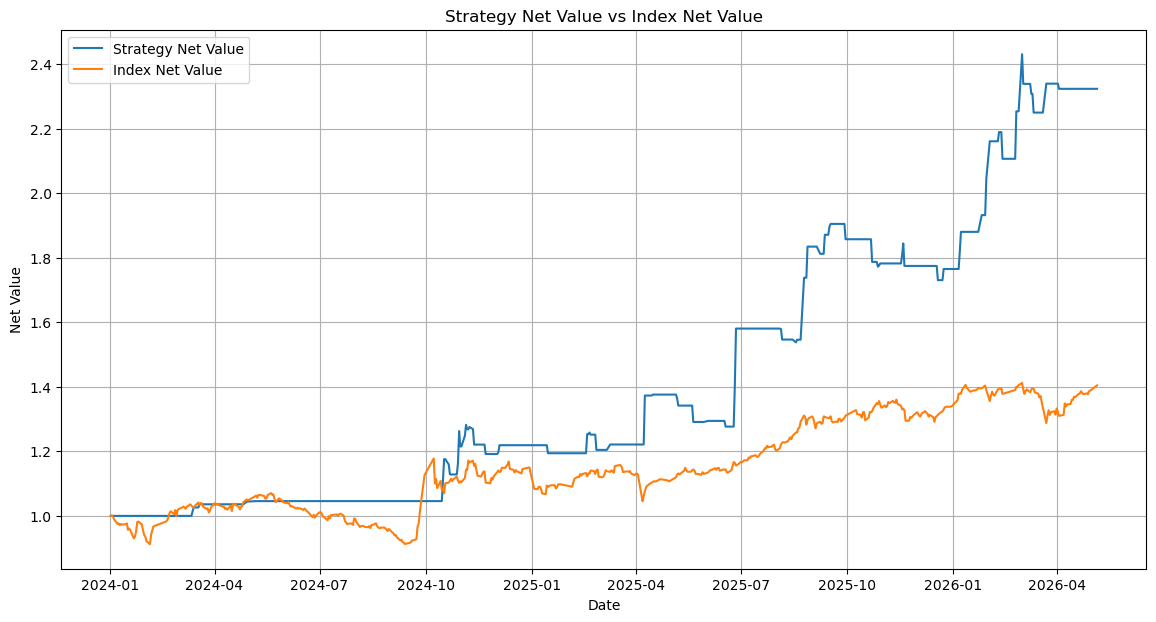

      指标名称        指标值
    回测开始日期 2024-01-02
    回测结束日期 2026-05-06
      策略胜率     52.22%
     策略盈亏比       1.86
 每单位风险期望收益     0.4922
    策略总收益率    132.35%
   策略年化收益率     43.32%
      最大回撤     -9.15%
  最大回撤开始日期 2025-09-17
  最大回撤结束日期 2025-12-19
      夏普比率       1.65
 策略超额年化收益率     27.72%
      最终净值     2.3235
每日平均买入股票个数       1.27
    平均持仓天数     3.49 天


In [27]:
# === 资金曲线/报告展示 ===
print(f"report_position_weight: {params_dict['position_weight']:.0%}")
print(f'report_trade_count: {len(valid_result)}')
if not valid_result.empty:
    # 这里把单笔收益按仓位权重折算成组合收益，更贴近实际资金曲线。
    valid_result['weight_profit'] = valid_result['profit'] * params_dict['position_weight']
    try:
        # 优先尝试画图，方便直接看净值曲线、回撤和胜率等指标。
        back_result = report_backtest_full(
            valid_result,
            start_date=start_date_str,
            end_date=end_date_str,
            profit_col='weight_profit',
            return_method='compound',
            plot=True
        )
    except Exception as e:
        # 如果绘图环境有问题，就至少把统计报表跑出来，不影响结果查看。
        print(f'plot failed, fallback to plot=False: {e}')
        back_result = report_backtest_full(
            valid_result,
            start_date=start_date_str,
            end_date=end_date_str,
            profit_col='weight_profit',
            return_method='compound',
            plot=False
        )
    print(back_result.to_string(index=False))
else:
    print('no valid backtest result')